In [1]:
!pip install sentence-transformers -q

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent century in the final over.",
    "India won the Test match by an innings and 50 runs.",
    "The spin bowler took a hat-trick on a dusty pitch.",
    "The fielder took a stunning catch near the boundary rope.",
    # Cooking (3 sentences)
    "Simmer the onions in butter until they turn golden brown.",
    "Add a pinch of turmeric and cumin seeds to the hot oil.",
    "Knead the dough gently until it becomes smooth and elastic.",
    # Cybersecurity (3 sentences)
    "The hacker exploited a zero-day vulnerability in the web server.",
    "Two-factor authentication significantly reduces the risk of account breaches.",
    "A distributed denial-of-service attack overwhelmed the company's infrastructure."
]

labels = [
    "Cricket-1","Cricket-2","Cricket-3","Cricket-4",
    "Cooking-1","Cooking-2","Cooking-3",
    "Cyber-1","Cyber-2","Cyber-3"
]

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(f"Embedding shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


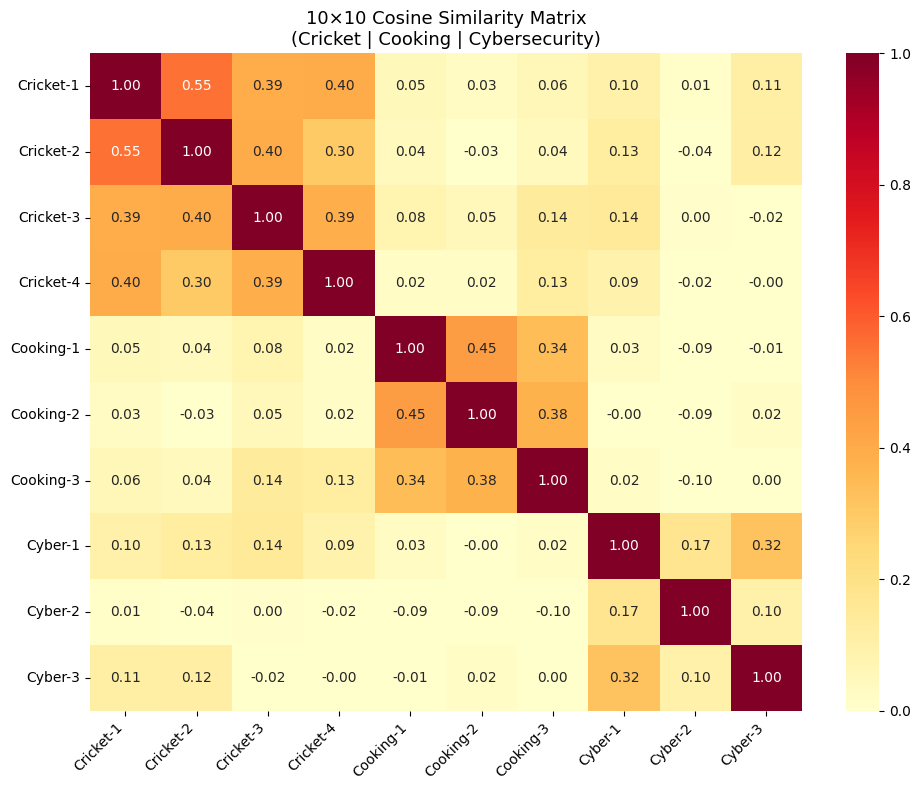

In [4]:
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1
)
plt.title("10×10 Cosine Similarity Matrix\n(Cricket | Cooking | Cybersecurity)", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()

In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

query_sims = cosine_similarity(query_embedding, embeddings)[0]
top2_idx = np.argsort(query_sims)[::-1][:2]

print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:")
for rank, idx in enumerate(top2_idx, 1):
    print(f"  {rank}. [{labels[idx]}] \"{sentences[idx]}\"")
    print(f"     Similarity Score: {query_sims[idx]:.4f}")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
  1. [Cricket-1] "The batsman hit a magnificent century in the final over."
     Similarity Score: 0.5936
  2. [Cricket-3] "The spin bowler took a hat-trick on a dusty pitch."
     Similarity Score: 0.5808
